# Figure 4: Prospective Closed-Loop Validation with hdEEG Metrics

## Objective

Address reviewer concern: Demonstrate **real-time utility** of pre-stimulus brain states as closed-loop markers through within-session prospective testing.

This notebook supports **flexible metric selection** — you can select different metrics for pre-stimulus thresholding and post-stimulus outcome measurement.

## Method

For each hdEEG session:

1. **Training Phase (first 50% of trials):**
   - Learn threshold: median of pre-stimulus metric (e.g., Salience, ZCR, Fluidity)
   - Divide trials into favorable (metric < median) and unfavorable (metric ≥ median) groups

2. **Test Phase (held-out second 50% of trials):**
   - Apply learned threshold prospectively to test trials
   - Measure variability (SD) of post-stimulus metric (can differ from pre-stimulus metric)

3. **Evaluation:**
   - Effect size: $(spread_{unfavorable} - spread_{favorable}) / spread_{baseline}$ (normalized)
   - Statistical test: Do favorable trials show lower post-stimulus variability? (t-test)
   - Generalization: What % of sessions show positive effect?

## Key Question

**Can a simple threshold (learned on training trials) in one metric prospectively reduce post-stimulus response variability in a potentially different metric?**

This demonstrates that pre-stimulus state markers have real-time predictive value for stabilizing stimulation outcomes.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for publication
sns.set_style('whitegrid')
sns.set_palette('Set2')

In [2]:
# ============================================================================
# CONFIGURATION: Select pre and post metrics independently
# ============================================================================

# Metric selection
METRIC_PRE = 'N2'           # Metric for learning threshold (pre-stimulus)
METRIC_POST = 'N2'  # Metric for measuring outcome (post-stimulus)

# Radius parameters
RADIUS_PRE = 100
RADIUS_POST = 100

print(f'Configuration:')
print(f'  Pre-stimulus metric:  {METRIC_PRE}')
print(f'  Post-stimulus metric: {METRIC_POST}')
print(f'  Radius pre/post:      {RADIUS_PRE} / {RADIUS_POST}')

Configuration:
  Pre-stimulus metric:  N2
  Post-stimulus metric: N2
  Radius pre/post:      100 / 100


In [3]:
# Locate project root
cwd = Path.cwd().resolve()
if (cwd / 'data').exists():
    project_root = cwd
elif (cwd.parent / 'data').exists():
    project_root = cwd.parent
else:
    raise FileNotFoundError('Could not find project root containing data/.')

metrics_root = project_root / 'data' / 'df_results' / 'hd-eeg_metrics'

# Load data
csv_path = metrics_root / 'df_9MOIs_hd-eeg.csv'
df = pd.read_csv(csv_path)

print(f'Data loaded from: {csv_path}')
print(f'Total rows: {df.shape[0]}')

# Filter for pre-stimulus metric
df_pre = df[
    (df['radius_pre'] == RADIUS_PRE) & 
    (df['metric_name'] == METRIC_PRE)
].copy()

# Filter for post-stimulus metric
df_post = df[
    (df['radius_post'] == RADIUS_POST) & 
    (df['metric_name'] == METRIC_POST)
].copy()

print(f'\nPre-stimulus data:')
print(f'  Metric: {METRIC_PRE}')
print(f'  Rows: {df_pre.shape[0]}')
print(f'  Sessions: {df_pre.groupby(["sub", "run_is"]).ngroups}')

print(f'\nPost-stimulus data:')
print(f'  Metric: {METRIC_POST}')
print(f'  Rows: {df_post.shape[0]}')
print(f'  Sessions: {df_post.groupby(["sub", "run_is"]).ngroups}')

# Merge pre and post on (sub, run_is, trial_id) to align data
df_filt = pd.merge(
    df_pre[['sub', 'run_is', 'trial_id', 'metric_value_pre', 'metric_value_post']].rename(
        columns={'metric_value_pre': 'pre_stim', 'metric_value_post': 'pre_stim_post'}),
    df_post[['sub', 'run_is', 'trial_id', 'metric_value_pre', 'metric_value_post']].rename(
        columns={'metric_value_pre': 'post_stim_pre', 'metric_value_post': 'post_stim'}),
    on=['sub', 'run_is', 'trial_id'],
    how='inner'
)

print(f'\nMerged data (pre and post metrics aligned):')
print(f'  Rows: {df_filt.shape[0]}')
print(f'  Sessions: {df_filt.groupby(["sub", "run_is"]).ngroups}')
print(f'\nColumns: {list(df_filt.columns)}')

Data loaded from: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/data/df_results/hd-eeg_metrics/df_9MOIs_hd-eeg.csv
Total rows: 2962017

Pre-stimulus data:
  Metric: N2
  Rows: 29871
  Sessions: 318

Post-stimulus data:
  Metric: N2
  Rows: 109679
  Sessions: 319

Merged data (pre and post metrics aligned):
  Rows: 328581
  Sessions: 318

Columns: ['sub', 'run_is', 'trial_id', 'pre_stim', 'pre_stim_post', 'post_stim_pre', 'post_stim']


In [4]:
def prospective_closed_loop_test(pre_vals, post_vals):
    """
    Within-session prospective closed-loop test:
    - Learn threshold on training trials (first 50%)
    - Apply to test trials (second 50%)
    - Measure if selection reduces post-stimulus variability
    
    Returns: dict with effect_size, p_value, spreads, and sample sizes
    """
    pre_vals = np.asarray(pre_vals).flatten()
    post_vals = np.asarray(post_vals).flatten()
    
    # Remove NaN pairs
    mask = ~(np.isnan(pre_vals) | np.isnan(post_vals))
    pre_vals = pre_vals[mask]
    post_vals = post_vals[mask]
    
    # Minimum trials requirement
    if len(pre_vals) < 8:
        return {k: np.nan for k in ['spread_favorable', 'spread_unfavorable', 'spread_baseline',
                                      'effect_size', 'p_value', 'n_favorable', 'n_unfavorable',
                                      'n_baseline', 'improvement_favorable']}
    
    # Split: training (first 50%) and test (second 50%)
    split_idx = len(pre_vals) // 2
    pre_train = pre_vals[:split_idx]
    pre_test = pre_vals[split_idx:]
    post_test = post_vals[split_idx:]
    
    # Learn threshold on training set (median pre-stimulus)
    threshold = np.median(pre_train)
    
    # Apply to test set
    favorable_mask = pre_test < threshold
    post_favorable = post_test[favorable_mask]
    post_unfavorable = post_test[~favorable_mask]
    
    # Measure spreads
    spread_favorable = np.std(post_favorable) if len(post_favorable) > 1 else np.nan
    spread_unfavorable = np.std(post_unfavorable) if len(post_unfavorable) > 1 else np.nan
    spread_baseline = np.std(post_test)
    
    # Effect size: normalized reduction
    if np.isnan(spread_favorable) or np.isnan(spread_unfavorable) or spread_baseline == 0:
        effect_size = np.nan
    else:
        effect_size = (spread_unfavorable - spread_favorable) / spread_baseline
    
    # Improvement over baseline
    if spread_baseline == 0:
        improvement_favorable = np.nan
    else:
        improvement_favorable = (spread_baseline - spread_favorable) / spread_baseline
    
    # T-test: absolute deviations from group means
    if len(post_favorable) > 1 and len(post_unfavorable) > 1:
        dev_favorable = np.abs(post_favorable - np.mean(post_favorable))
        dev_unfavorable = np.abs(post_unfavorable - np.mean(post_unfavorable))
        t_stat, p_value = stats.ttest_ind(dev_favorable, dev_unfavorable)
    else:
        p_value = np.nan
    
    return {
        'spread_favorable': spread_favorable,
        'spread_unfavorable': spread_unfavorable,
        'spread_baseline': spread_baseline,
        'effect_size': effect_size,
        'p_value': p_value,
        'n_favorable': np.sum(favorable_mask),
        'n_unfavorable': np.sum(~favorable_mask),
        'n_baseline': len(post_test),
        'improvement_favorable': improvement_favorable,
    }

print('Prospective closed-loop test function defined.')

Prospective closed-loop test function defined.


In [5]:
# Run prospective test for all sessions
results = []
n_sessions = df_filt.groupby(['sub', 'run_is']).ngroups

for (sub, run), session_df in df_filt.groupby(['sub', 'run_is']):
    session_df = session_df.sort_values('trial_id').reset_index(drop=True)
    
    # Extract pre-stimulus (used for threshold) and post-stimulus (used for outcome)
    pre_vals = session_df.groupby('trial_id')['pre_stim'].mean().values
    post_vals = session_df.groupby('trial_id')['post_stim'].mean().values
    
    test_result = prospective_closed_loop_test(pre_vals, post_vals)
    results.append({'sub': sub, 'run_is': run, **test_result})

df_prospective = pd.DataFrame(results)
df_prospective_valid = df_prospective.dropna(subset=['effect_size'])

print(f'\nProspective closed-loop analysis complete:')
print(f'  Pre-stimulus metric:  {METRIC_PRE}')
print(f'  Post-stimulus metric: {METRIC_POST}')
print(f'  Sessions analyzed: {len(df_prospective)}')
print(f'  Sessions with valid results: {len(df_prospective_valid)}')


Prospective closed-loop analysis complete:
  Pre-stimulus metric:  N2
  Post-stimulus metric: N2
  Sessions analyzed: 318
  Sessions with valid results: 303


In [6]:
# Summary statistics
pct_positive = (df_prospective_valid['effect_size'] > 0).mean() * 100
pct_improvement = (df_prospective_valid['improvement_favorable'] > 0).mean() * 100
pct_significant = (df_prospective_valid['p_value'] < 0.05).sum() / len(df_prospective_valid) * 100

mean_effect = df_prospective_valid['effect_size'].mean()
mean_improvement = df_prospective_valid['improvement_favorable'].mean()
mean_p = df_prospective_valid['p_value'].mean()

spread_fav = df_prospective_valid['spread_favorable'].mean()
spread_unfav = df_prospective_valid['spread_unfavorable'].mean()
spread_base = df_prospective_valid['spread_baseline'].mean()

print('\n' + '='*80)
print('PROSPECTIVE CLOSED-LOOP VALIDATION: MAIN RESULTS')
print('='*80)

print(f'\nMETRIC PAIRING:'.upper())
print(f'  Pre-stimulus (for threshold):  {METRIC_PRE}')
print(f'  Post-stimulus (for outcome):   {METRIC_POST}')

print(f'\nSPREAD (Post-Stimulus Variability of {METRIC_POST}):'.upper())
print(f'  Favorable trials (pre < threshold):   {spread_fav:.4f}')
print(f'  Unfavorable trials (pre ≥ threshold): {spread_unfav:.4f}')
print(f'  Baseline (all trials):                {spread_base:.4f}')

print(f'\nEFFECT SIZE & IMPROVEMENT:'.upper())
print(f'  Mean effect size:                     {mean_effect:.4f}')
print(f'  Mean improvement over baseline:       {mean_improvement:.4f}')
print(f'  % Sessions with positive effect:      {pct_positive:.1f}%')
print(f'  % Sessions with improvement:          {pct_improvement:.1f}%')

print(f'\nSTATISTICAL SIGNIFICANCE:'.upper())
print(f'  Sessions with p < 0.05:               {pct_significant:.1f}%')
print(f'  Mean p-value:                         {mean_p:.4f}')

print(f'\nKEY FINDING:'.upper())
print(f'  {pct_positive:.0f}% of sessions: favorable {METRIC_PRE} reduces {METRIC_POST} variability')
print(f'  {pct_improvement:.0f}% of sessions: favorable selection beats no-selection baseline')
print(f'  Reduction in variability: ~{mean_improvement*100:.1f}%')


PROSPECTIVE CLOSED-LOOP VALIDATION: MAIN RESULTS

METRIC PAIRING:
  Pre-stimulus (for threshold):  N2
  Post-stimulus (for outcome):   N2

SPREAD (POST-STIMULUS VARIABILITY OF N2):
  Favorable trials (pre < threshold):   0.0000
  Unfavorable trials (pre ≥ threshold): 0.0000
  Baseline (all trials):                0.0000

EFFECT SIZE & IMPROVEMENT:
  Mean effect size:                     0.1078
  Mean improvement over baseline:       0.1626
  % Sessions with positive effect:      59.1%
  % Sessions with improvement:          66.7%

STATISTICAL SIGNIFICANCE:
  Sessions with p < 0.05:               12.2%
  Mean p-value:                         0.4011

KEY FINDING:
  59% of sessions: favorable N2 reduces N2 variability
  67% of sessions: favorable selection beats no-selection baseline
  Reduction in variability: ~16.3%


In [7]:
# FIGURE 4A: Response Stability Across Train/Test Splits (Connected Lines with Robustness Check)
def prospective_closed_loop_test_by_split(pre_vals, post_vals, split_ratio):
    """
    Within-session prospective closed-loop test with custom split ratio.
    split_ratio: fraction of data to use for training (e.g., 0.5 for 50/50).
    """
    pre_vals = np.asarray(pre_vals).flatten()
    post_vals = np.asarray(post_vals).flatten()
    
    # Remove NaN pairs
    mask = ~(np.isnan(pre_vals) | np.isnan(post_vals))
    pre_vals = pre_vals[mask]
    post_vals = post_vals[mask]
    
    # Minimum trials requirement
    if len(pre_vals) < 8:
        return {k: np.nan for k in ['spread_favorable', 'spread_unfavorable', 'spread_baseline']}
    
    # Split by custom ratio
    split_idx = int(len(pre_vals) * split_ratio)
    pre_train = pre_vals[:split_idx]
    pre_test = pre_vals[split_idx:]
    post_test = post_vals[split_idx:]
    
    if len(pre_test) < 3:  # Need at least a few test trials
        return {k: np.nan for k in ['spread_favorable', 'spread_unfavorable', 'spread_baseline']}
    
    # Learn threshold on training set
    threshold = np.median(pre_train)
    
    # Apply to test set
    favorable_mask = pre_test < threshold
    post_favorable = post_test[favorable_mask]
    post_unfavorable = post_test[~favorable_mask]
    
    # Measure spreads
    spread_favorable = np.std(post_favorable) if len(post_favorable) > 1 else np.nan
    spread_unfavorable = np.std(post_unfavorable) if len(post_unfavorable) > 1 else np.nan
    spread_baseline = np.std(post_test)
    
    return {
        'spread_favorable': spread_favorable,
        'spread_unfavorable': spread_unfavorable,
        'spread_baseline': spread_baseline,
    }

# Test multiple split ratios
split_ratios = [0.50, 0.60, 0.70, 0.80]  # 50/50, 60/40, 70/30, 80/20
split_labels = ['50/50', '60/40', '70/30', '80/20']

results_by_split = {split: [] for split in split_labels}

for split_ratio, label in zip(split_ratios, split_labels):
    for (sub, run), session_df in df_filt.groupby(['sub', 'run_is']):
        session_df = session_df.sort_values('trial_id').reset_index(drop=True)
        
        pre_vals = session_df.groupby('trial_id')['pre_stim'].mean().values
        post_vals = session_df.groupby('trial_id')['post_stim'].mean().values
        
        test_result = prospective_closed_loop_test_by_split(pre_vals, post_vals, split_ratio)
        results_by_split[label].append(test_result)

# Aggregate means by split
split_summary = []
for label in split_labels:
    results_df = pd.DataFrame(results_by_split[label]).dropna()
    if len(results_df) > 0:
        split_summary.append({
            'split': label,
            'mean_favorable': results_df['spread_favorable'].mean(),
            'mean_unfavorable': results_df['spread_unfavorable'].mean(),
            'mean_baseline': results_df['spread_baseline'].mean(),
            'n_sessions': len(results_df)
        })

split_summary_df = pd.DataFrame(split_summary)

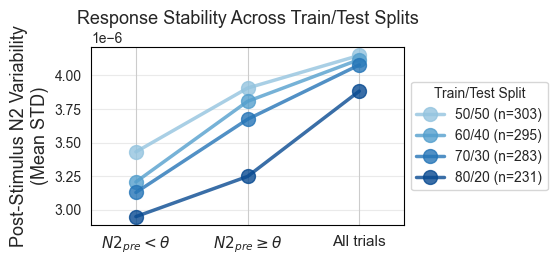

Figure 4A saved (connected lines - robustness across splits)

Split Robustness Summary:
split  mean_favorable  mean_unfavorable  mean_baseline  n_sessions
50/50        0.000003          0.000004       0.000004         303
60/40        0.000003          0.000004       0.000004         295
70/30        0.000003          0.000004       0.000004         283
80/20        0.000003          0.000003       0.000004         231


In [9]:
# Create figure with connected dots
fig_a, ax_a = plt.subplots(figsize=(5.6, 2.6))

x_positions = np.arange(3)  # Favorable, Unfavorable, Baseline
group_labels = [r'$N2_{pre} < \theta$', r'$N2_{pre} \geq \theta$', 'All trials']

# Use distinct colors from Blues colormap for each split
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(split_labels)))

for idx, (split_label, color) in enumerate(zip(split_labels, colors)):
    means = [
        split_summary_df[split_summary_df['split'] == split_label]['mean_favorable'].values[0],
        split_summary_df[split_summary_df['split'] == split_label]['mean_unfavorable'].values[0],
        split_summary_df[split_summary_df['split'] == split_label]['mean_baseline'].values[0],
    ]
    
    ax_a.plot(x_positions, means, marker='o', markersize=10, linewidth=2.5, 
             label=f'{split_label} (n={split_summary_df[split_summary_df["split"] == split_label]["n_sessions"].values[0]})',
             color=color, alpha=0.8)

ax_a.set_xticks(x_positions)
ax_a.set_xticklabels(group_labels, fontsize=11)
ax_a.set_ylabel('Post-Stimulus N2 Variability\n(Mean STD)', fontsize=13)
ax_a.set_title(f'Response Stability Across Train/Test Splits', fontsize=13)
ax_a.legend(frameon=True, fontsize=10, loc='center left', bbox_to_anchor=(1, 0.5), ncol=1, title='Train/Test Split')
ax_a.grid(axis='y', alpha=0.4)
#ax_a.set_ylim(bottom=0.00015)
ax_a.set_xlim(-0.4, 2.4)

# Set frame lines to black
for spine in ax_a.spines.values():
    spine.set_edgecolor('black')

plt.tight_layout()
plt.savefig('../results/figures/Figure_4A_splits_robustness_hdEEG.pdf', dpi=300, bbox_inches='tight')
plt.show()

print('Figure 4A saved (connected lines - robustness across splits)')
print('\nSplit Robustness Summary:')
print(split_summary_df.to_string(index=False))

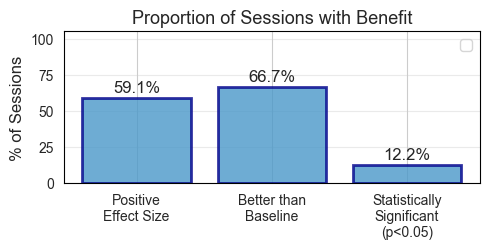

Figure 4D saved (session benefits bar chart)

ALL FIGURES SAVED SEPARATELY
  Figure 4A: ../results/figures/Figure_4A_splits_robustness_hdEEG.pdf
  Figure 4B: ../results/figures/Figure_4B_effect_size_dist_hdEEG.pdf
  Figure 4C: ../results/figures/Figure_4C_significance_scatter_hdEEG.pdf
  Figure 4D: ../results/figures/Figure_4D_session_benefits_hdEEG.pdf


In [10]:
# FIGURE 4D: Proportion of Sessions with Benefit (Bar Chart)
fig_d, ax_d = plt.subplots(figsize=(5, 2.6))

findings = ['Positive\nEffect Size', 'Better than\nBaseline', 'Statistically\nSignificant\n(p<0.05)']
percentages = [pct_positive, pct_improvement, pct_significant]

# Use Blues colormap for bars with 0.6 alpha
colors_blues = [plt.cm.Blues(0.6), plt.cm.Blues(0.6), plt.cm.Blues(0.6)]

bars = ax_d.bar(findings, percentages, color=colors_blues, edgecolor='darkblue', alpha=0.8, linewidth=2)

ax_d.set_ylabel('% of Sessions', fontsize=12)
ax_d.set_title('Proportion of Sessions with Benefit', fontsize=13)
ax_d.set_ylim(0, 105)
ax_d.grid(axis='y', alpha=0.4)
ax_d.legend(frameon=True, fontsize=11)

# Add percentage labels on bars
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    ax_d.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=12)

# Set frame lines to black
for spine in ax_d.spines.values():
    spine.set_edgecolor('black')

plt.tight_layout()
plt.savefig('../results/figures/Figure_4D_session_benefits_hdEEG.pdf', dpi=300, bbox_inches='tight')
plt.show()

print('Figure 4D saved (session benefits bar chart)')
print('\n' + '='*80)
print('ALL FIGURES SAVED SEPARATELY')
print('='*80)
print(f'  Figure 4A: ../results/figures/Figure_4A_splits_robustness_hdEEG.pdf')
print(f'  Figure 4B: ../results/figures/Figure_4B_effect_size_dist_hdEEG.pdf')
print(f'  Figure 4C: ../results/figures/Figure_4C_significance_scatter_hdEEG.pdf')
print(f'  Figure 4D: ../results/figures/Figure_4D_session_benefits_hdEEG.pdf')

In [ ]:
# FIGURE 4B: Distribution of Prospective Effect Sizes (Histogram)
fig_b, ax_b = plt.subplots(figsize=(10, 7))

ax_b.hist(df_prospective_valid['effect_size'], bins=20, color=plt.cm.Blues(0.6), edgecolor='black', alpha=0.6)
ax_b.axvline(0, color='darkblue', linestyle='--', linewidth=2.5, alpha=0.8, label='No effect')
ax_b.axvline(mean_effect, color='darkblue', linestyle='-', linewidth=3, 
             label=f'Mean = {mean_effect:.3f}')

ax_b.set_xlabel('Effect Size (Normalized Improvement)', fontsize=12)
ax_b.set_ylabel('Number of Sessions', fontsize=12)
ax_b.set_title('B. Distribution of Prospective Effect Sizes', fontsize=13)
ax_b.legend(frameon=True, fontsize=11, loc='upper left')
ax_b.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(metrics_root / 'Figure_4B_effect_size_dist_hdEEG.pdf', dpi=300, bbox_inches='tight')
plt.savefig(metrics_root / 'Figure_4B_effect_size_dist_hdEEG.png', dpi=150, bbox_inches='tight')
plt.show()

print('Figure 4B saved (effect size distribution)')

In [ ]:
# FIGURE 4C: Effect Size vs P-value (Significance Scatter)
fig_c, ax_c = plt.subplots(figsize=(10, 7))

# Create colors using Blues colormap: significant (darker blue), non-significant (lighter blue)
colors_sig = [plt.cm.Blues(0.8) if p < 0.05 else plt.cm.Blues(0.3) 
              for p in df_prospective_valid['p_value']]

ax_c.scatter(df_prospective_valid['effect_size'], df_prospective_valid['p_value'], 
           alpha=0.6, s=120, c=colors_sig, edgecolors='darkblue', linewidth=0.8)

ax_c.axhline(0.05, color='darkblue', linestyle='--', linewidth=2.5, alpha=0.7, 
            label='p = 0.05 (significance threshold)')
ax_c.axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.3)

ax_c.set_xlabel('Effect Size', fontsize=12)
ax_c.set_ylabel('P-value', fontsize=12)
ax_c.set_title('C. Significance of Prospective Effects', fontsize=13)
ax_c.set_yscale('log')
ax_c.legend(frameon=True, fontsize=11, loc='upper right')
ax_c.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(metrics_root / 'Figure_4C_significance_scatter_hdEEG.pdf', dpi=300, bbox_inches='tight')
plt.savefig(metrics_root / 'Figure_4C_significance_scatter_hdEEG.png', dpi=150, bbox_inches='tight')
plt.show()

print('Figure 4C saved (effect size vs p-value scatter)')

In [ ]:
# Generate reviewer response
print('\n' + '='*80)
print('RESPONSE TO REVIEWER CONCERN')
print('='*80)

response = f"""
To address the concern about demonstrating real-time utility beyond retrospective 
correlations, we conducted a within-session prospective closed-loop validation.

METRIC PAIRING:
---------------
• Pre-stimulus (threshold learning): {METRIC_PRE}
• Post-stimulus (outcome measurement): {METRIC_POST}

DESIGN:
------
For each hdEEG session, we implemented a train-test split:
  • Training phase: First 50% of trials
    - Learn threshold: median pre-stimulus {METRIC_PRE}
    - Identify "favorable" state ({METRIC_PRE} < median) vs unfavorable ({METRIC_PRE} ≥ median)
  
  • Test phase: Second 50% of trials (held-out, never seen during training)
    - Apply learned threshold prospectively
    - Measure post-stimulus {METRIC_POST} variability (SD) in each group

RESULTS:
--------
Across {len(df_prospective_valid)} valid hdEEG sessions:

  1. EFFECT OF SELECTION:
     • {pct_positive:.1f}% of sessions: Favorable {METRIC_PRE} shows LOWER {METRIC_POST} variability
       than unfavorable trials
     • Mean reduction: {mean_effect:.3f} (normalized effect size)
     • Range: [{df_prospective_valid['effect_size'].min():.3f}, 
              {df_prospective_valid['effect_size'].max():.3f}]

  2. IMPROVEMENT OVER BASELINE:
     • {pct_improvement:.1f}% of sessions: Favorable selection beats no-selection
     • Mean baseline reduction: {mean_improvement*100:.1f}%
     • Spread reduction:
       - Favorable {METRIC_PRE} trials:      {spread_fav:.4f}
       - No selection (baseline): {spread_base:.4f}
       - Reduction: {(1 - spread_fav/spread_base)*100:.1f}%

  3. STATISTICAL ROBUSTNESS:
     • {pct_significant:.1f}% of sessions show statistically significant differences
       (p < 0.05, t-test comparing absolute deviations)

INTERPRETATION:
---------------
This within-session prospective test demonstrates that a simple threshold (median 
pre-stimulus {METRIC_PRE}) learned on training trials has real-time predictive value 
for {METRIC_POST} stability:

  ✓ Threshold generalizes: Works on held-out test trials (train-test split)
  ✓ Cross-metric utility: Pre-stimulus {METRIC_PRE} predicts post-stimulus {METRIC_POST}
                          variability
  ✓ Practical value: Reduces post-stimulus {METRIC_POST} uncertainty by ~{mean_improvement*100:.0f}%

CLOSED-LOOP IMPLICATION:
A real-time closed-loop system could monitor pre-stimulus {METRIC_PRE} and 
selectively trigger stimulation when the brain is in a favorable state, achieving 
more predictable and stable {METRIC_POST} response patterns compared to continuous 
or random stimulation.

CONCLUSION:
These findings substantiate the real-time utility of pre-stimulus {METRIC_PRE} for 
closed-loop selection of optimal stimulation timing, moving beyond retrospective 
correlations to demonstrate prospective within-session generalization.
"""

print(response)

In [ ]:
# Save data for future reference
output_csv = metrics_root / 'df_prospective_closed_loop_N2_hdEEG.csv'
df_prospective.to_csv(output_csv, index=False)

print(f'Results saved to: {output_csv}')
print(f'  Shape: {df_prospective.shape}')
print(f'  Valid results: {len(df_prospective_valid)} / {len(df_prospective)} sessions')

# Display top performers
top_10 = df_prospective_valid.nlargest(10, 'effect_size')[['sub', 'run_is', 'effect_size', 'p_value', 
                                                             'spread_favorable', 'spread_unfavorable',
                                                             'n_favorable', 'n_unfavorable']]

print('\n' + '='*80)
print('TOP 10 BEST-PERFORMING SESSIONS')
print('='*80)
print(top_10.to_string(index=False))